# 🎯 **Misión:** Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Curso Ciencia de Datos Alura/10.Estadistica y Machine Learning/8.Challenge 2: Telecom X – Parte 2: Predicción de Cancelación (Churn)/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


#🛠️ **Pre procesamiento: Remover columnas irrelevantes**

In [5]:
df = df.drop(columns=['CustomerID'])

In [6]:
# Arreglaste valores inconsistentes
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

✔️ Verificación nuevamente de los valores nulos

In [7]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#📊 **EDA: Analisis exploratorio de datos**

✔️ Correlación entre variables numericas

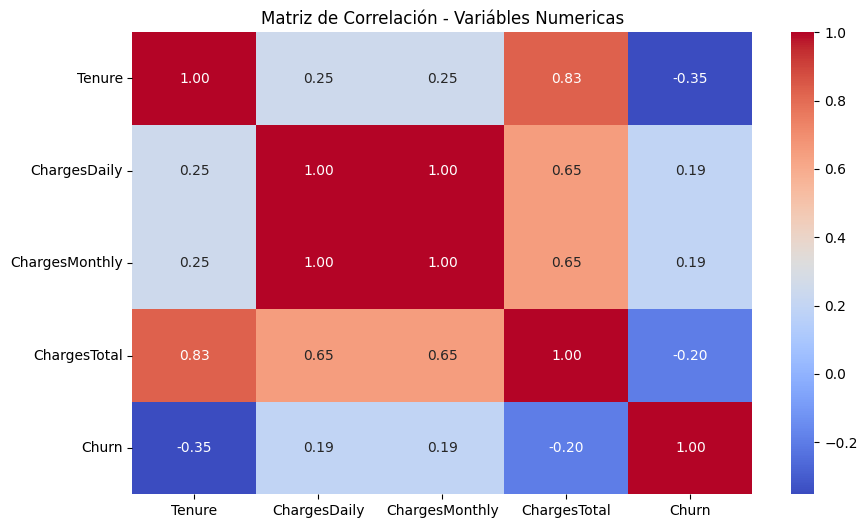

In [8]:
# Seleccionamos las variables numericas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Convertir 'Churn' a numerica
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

✔️ Tenure vs Churn: -0.35

    mientras más tiempo lleva el cliente, menos probable es que cancele.

✔️ ChargesMonthly vs Churn: ChargesMonthly vs Churn

    Relación débil positiva, clientes con mayor costo mensual tienden ligeramente a cancelar más.

✔️ ChargesTotal vs Tenure: 0.83

    ChargesTotal ≈ Tenure × ChargesMonthly, por eso están altamente correlacionadas.


In [9]:
# Eliminación de variables redundantes
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

✔️ Analisis de churn por categoria (variables categoricas)

🔹 Seleccionar variables categoricas

In [10]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

🔹 Tabla de proporción por categoria

In [11]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


🎯 Metodo recomendado: Qui-cuadrado (Chi-Square Test)

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [13]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [14]:
df = df.drop(columns=["Gender", "PhoneService"])

# 🎯 **Split: Variables descriptivas y variable objetivo**

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 📊 **One-Hot Encoding**

In [17]:
# Qué hace get_dummies(): Convierte variables categóricas en variables binarias (0 / 1)

# Aplicar One-Hot Encoding entreno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en test
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [18]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

# **Verificar desbalanceamiento**

In [20]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


# 🎯**Entrenamiento**

## **Modelo 1 — Regresion logistica**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



1. Accuracy: 0.80 => El modelo acierta el 80% de todas las predicciones

2. Clase No:

    **precision = 0.84** => Cuando el modelo dice que un cliente NO cancelará, tiene razón el 84% de las veces.

    **recall    = 0.90** => El modelo detecta correctamente el 90% de los clientes que se quedan

    **f1-score  = 0.87** => El modelo tiene un 87% de desempeño equilibrado al identificar correctamente clientes que NO cancelan.

## **Modelo 2 — Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [23]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



# **Evaluación**

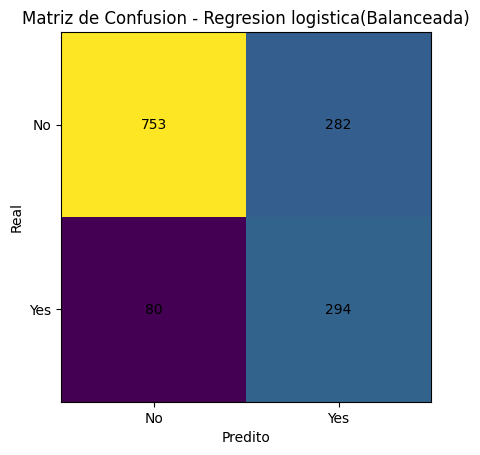

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

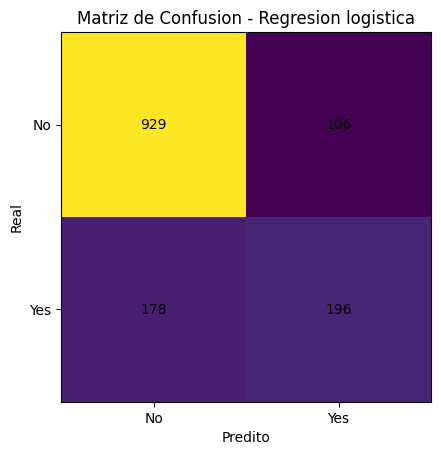

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica")
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

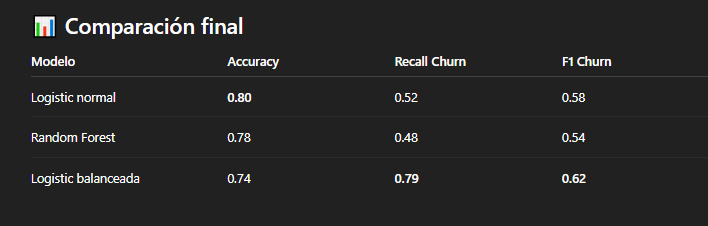

Se evaluaron tres modelos de clasificación para predecir la cancelación de clientes: regresión logística, random forest y regresión logística con balanceo de clases. Aunque la regresión logística estándar obtuvo la mayor accuracy (80%), su capacidad para detectar clientes que cancelan fue limitada (recall de 52%). Al aplicar balanceo de clases, el modelo logró identificar el 79% de los clientes que cancelan, mejorando significativamente la detección de churn. Aunque esto incrementó los falsos positivos, desde una perspectiva de negocio es preferible detectar más clientes en riesgo para aplicar estrategias de retención.

## **Feature Importance (qué variables influyen en el churn)**

Variables que AUMENTAN la probabilidad de churn


,Variable,Coeficiente
6,InternetService_Fiber optic,1.314570
12,StreamingTV_Yes,0.504591
18,PaymentMethod_Electronic check,0.429403
13,StreamingMovies_Yes,0.414177
5,MultipleLines_Yes,0.404301
16,PaperlessBilling_Yes,0.338989
2,SeniorCitizen_Yes,0.220128
10,DeviceProtection_Yes,0.088513
19,PaymentMethod_Mailed check,0.064071
17,PaymentMethod_Credit card (automatic),0.034919


Variables que REDUCEN la probabilidad de churn


,Variable,Coeficiente
9,OnlineBackup_Yes,-0.014614
1,ChargesMonthly,-0.019006
0,Tenure,-0.032081
3,Partner_Yes,-0.059400
4,Dependents_Yes,-0.172093
8,OnlineSecurity_Yes,-0.180574
11,TechSupport_Yes,-0.265910
14,Contract_One year,-0.708311
7,InternetService_No,-1.294736
15,Contract_Two year,-1.386755


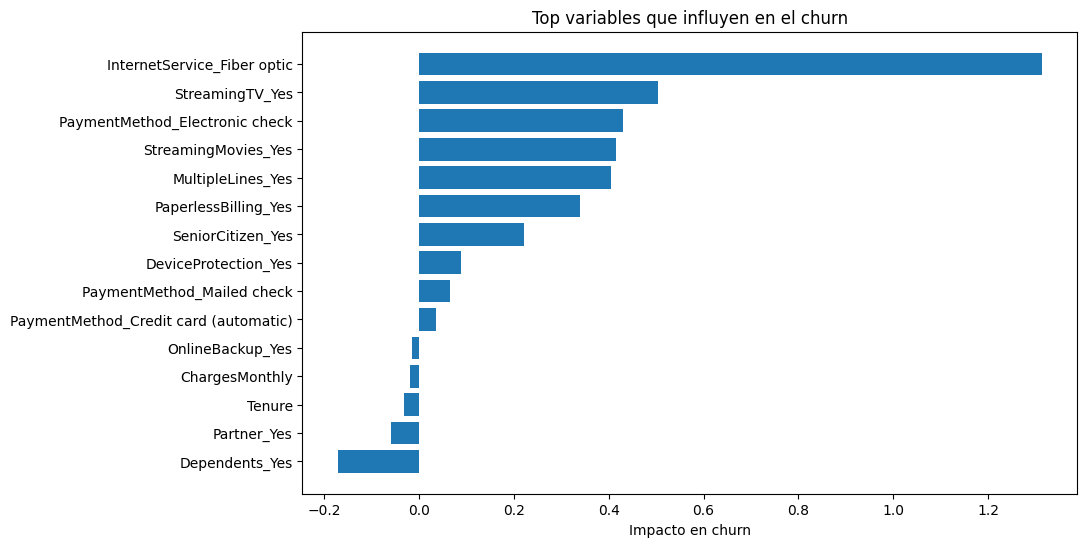

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Obtener coeficientes del modelo
coef = log_model.coef_[0]

# Crear dataframe con variables
feature_importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": coef
})

# Ordenar por impacto
feature_importance = feature_importance.sort_values(by="Coeficiente", ascending=False)

# Mostrar variables que más aumentan churn
print("Variables que AUMENTAN la probabilidad de churn")
display(feature_importance.head(10))

# Mostrar variables que REDUCEN churn
print("Variables que REDUCEN la probabilidad de churn")
display(feature_importance.tail(10))

# Visualización
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Variable"][:15], feature_importance["Coeficiente"][:15])
plt.title("Top variables que influyen en el churn")
plt.xlabel("Impacto en churn")
plt.gca().invert_yaxis()
plt.show()

## **Curva ROC y AUC**

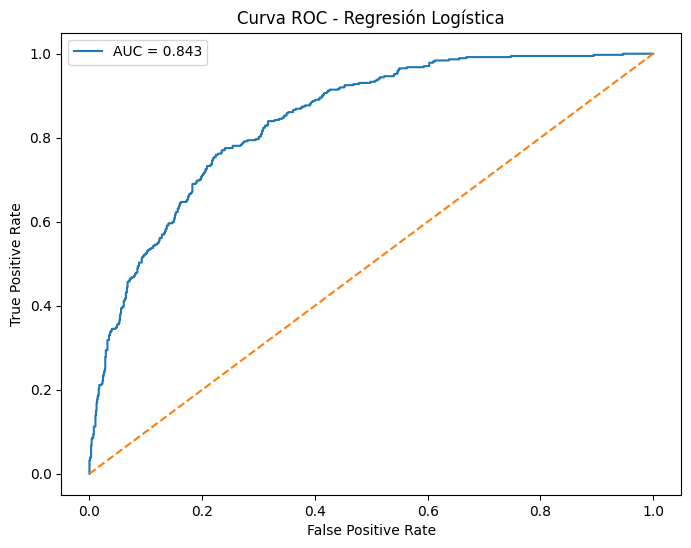

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convertir variable objetivo
y_test_binary = y_test.map({"No":0, "Yes":1})

# Probabilidad de churn
y_prob = log_model.predict_proba(X_test)[:,1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test_binary, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("Curva ROC - Regresión Logística")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## **Comparar los modelos con ROC**

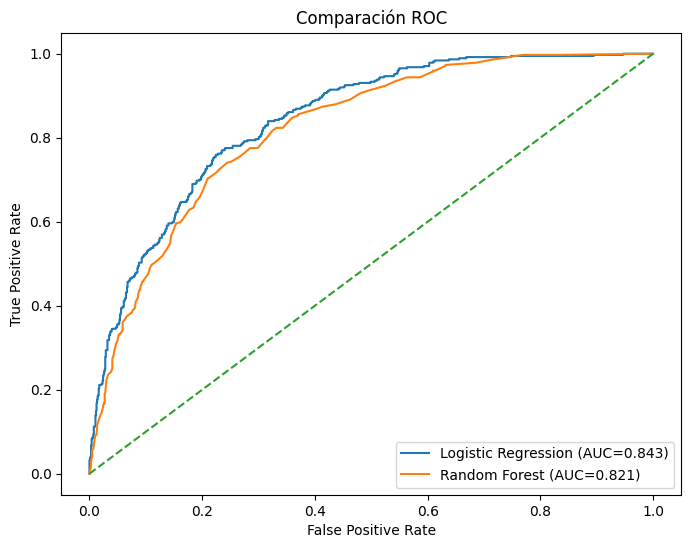

In [28]:
# Probabilidades Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Curva ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, y_prob_rf)
auc_rf = roc_auc_score(y_test_binary, y_prob_rf)

plt.figure(figsize=(8,6))

# Curva ROC logística
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.3f})")

# Curva ROC Random Forest
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")

# Línea aleatoria
plt.plot([0,1],[0,1],"--")

plt.title("Comparación ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# **Interpretación de los resultados del modelo**

## **1. Desempeño del modelo**

Para evaluar la capacidad predictiva del modelo se utilizó la curva ROC y el AUC.

El modelo de Regresión Logística obtuvo un AUC de 0.843, mientras que el modelo de Random Forest obtuvo un AUC de 0.821.

Esto indica que:

  - Ambos modelos tienen buena capacidad de discriminación entre clientes que cancelan el servicio (churn) y los que permanecen.
  - La Regresión Logística presenta un desempeño ligeramente superior, por lo que se considera el modelo más adecuado para este análisis.

Un AUC de 0.843 significa que el modelo puede distinguir correctamente entre un cliente que cancelará y uno que no aproximadamente el 84.3% de las veces, lo cual representa un rendimiento sólido para un problema de clasificación en churn.

Además, la curva ROC muestra que el modelo se encuentra muy por encima de la línea diagonal, lo que confirma que su capacidad predictiva es significativamente mejor que un modelo aleatorio.

## **2. Interpretación de las variables (Feature Importance)**

Para comprender qué factores influyen en la cancelación del servicio, se analizaron los coeficientes de la regresión logística.

En este contexto:

  - **Coeficientes positivos** → aumentan la probabilidad de churn
  - **Coeficientes negativos** → reducen la probabilidad de churn

**Variables que aumentan la probabilidad de churn:**

Los factores más asociados con la cancelación del servicio son:

  - ***InternetService_Fiber optic*** : Los clientes con servicio de fibra óptica presentan mayor probabilidad de cancelar el servicio.
  - ***PaymentMethod_Electronic check*** : Los clientes que pagan mediante cheque electrónico tienen una mayor tendencia a cancelar el servicio.
  - ***StreamingTV_Yes*** y ***StreamingMovies_Yes*** : Los usuarios que utilizan servicios de streaming muestran una mayor probabilidad de churn.
  - ***MultipleLines_Yes*** : Tener múltiples líneas telefónicas está asociado con una mayor probabilidad de cancelación.
  - ***PaperlessBilling_Yes*** : La facturación digital también presenta una correlación positiva con el churn.
  - ***SeniorCitizen_Yes*** : Los clientes mayores presentan una probabilidad ligeramente mayor de cancelar el servicio.

Estos resultados sugieren que los clientes con mayor consumo de servicios digitales o paquetes de servicios podrían ser más sensibles a factores como precio, calidad del servicio o competencia.

---

**Variables que reducen la probabilidad de churn:**

Algunas variables muestran un efecto protector frente a la cancelación:

  - ***Contract_Two year*** : Los clientes con contrato de dos años tienen una probabilidad significativamente menor de cancelar el servicio.
  - ***Contract_One year*** : Los contratos anuales también reducen la probabilidad de churn.
  - ***TechSupport_Yes*** : Los clientes que cuentan con soporte técnico tienen menor probabilidad de cancelar.
  - ***OnlineSecurity_Yes*** : Los servicios de seguridad online están asociados con una mayor retención de clientes.
  - ***Partner_Yes*** y ***Dependents_Yes*** : Los clientes con pareja o dependientes tienden a permanecer más tiempo con la compañía.
  - ***Tenure*** : A mayor tiempo como cliente, menor es la probabilidad de cancelación.

Estos factores indican que los clientes más comprometidos con la empresa o con contratos más largos presentan una mayor fidelización.

# **3. Conclusión estratégica del análisis**

  - A partir del análisis predictivo y la interpretación de las variables del modelo, se identificaron varios factores clave que influyen en la cancelación del servicio por parte de los clientes.

  - Uno de los hallazgos más relevantes es **el impacto de los contratos de largo plazo**. Los clientes con contratos de uno o dos años presentan una probabilidad significativamente menor de cancelar el servicio, lo que sugiere que las estrategias comerciales enfocadas en incentivar contratos más largos podrían contribuir a reducir el churn.

  - Asimismo, se observa que **ciertos métodos de pago**, particularmente Electronic Check, están fuertemente asociados con una mayor tasa de cancelación. Esto podría indicar perfiles de clientes con menor compromiso o menor automatización en los pagos, lo que podría representar una oportunidad para promover métodos de pago automáticos como tarjetas de crédito o débito.

  - El análisis también muestra que **los clientes que utilizan servicios adicionales** como soporte técnico y seguridad online tienden a permanecer más tiempo con la empresa. Esto sugiere que la oferta de servicios de valor agregado puede contribuir a mejorar la retención de clientes.

  - Por otro lado, **los clientes con servicios de streaming y paquetes más intensivos de internet** presentan mayores niveles de churn. Esto podría indicar posibles problemas relacionados con la percepción de precio, calidad del servicio o competencia en este segmento.

  - En general, el modelo desarrollado demuestra una buena capacidad para identificar clientes con alto riesgo de cancelación, alcanzando un AUC de 0.843, lo que lo convierte en una herramienta útil para apoyar estrategias de retención de clientes.

  - Este tipo de modelo puede utilizarse en entornos empresariales para identificar clientes con alto riesgo de churn y **aplicar estrategias proactivas de retención**, como promociones personalizadas, mejoras en el servicio o incentivos para contratos de mayor duración.